# Predictors Region Map

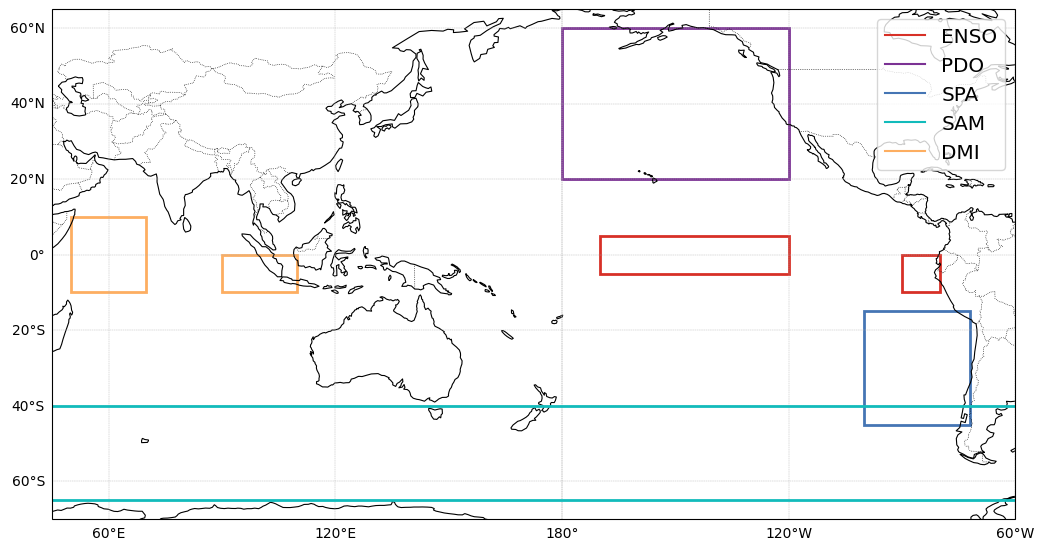

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines

# ---------------------------
# Helpers
# ---------------------------
def convert_lon(lon):
    return lon

def draw_box(ax, lon_min, lon_max, lat_min, lat_max, **kwargs):
    width = lon_max - lon_min
    
    rect = Rectangle(
        (lon_min, lat_min),
        width,
        lat_max - lat_min,
        transform=ccrs.PlateCarree(),  # 🔥 THIS FIXES IT
        **kwargs
    )
    
    ax.add_patch(rect)

# ---------------------------
# Figure setup (FIXED)
# ---------------------------
fig = plt.figure(figsize=(12, 6))

# 🔥 KEY FIX: make axis occupy full figure
proj = ccrs.PlateCarree(central_longitude=180)
ax = plt.axes([0.05, 0.1, 0.9, 0.85], projection=proj)

ax.set_extent([45, 300, -70, 65], crs=ccrs.PlateCarree())

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# ---------------------------
# Colors
# ---------------------------
colors = {
    "enso": "#d73027",
    "pdo": "#7b3294",
    "synoptic": "#4575b4",
    "dmi": "#fdae61",
    "advection": "#1a9850",
    "winds": "#333333",
    "sam": "#12BBBB"
}

# =========================
# Boxes (NO TEXT NOW)
# =========================

# ENSO
draw_box(ax, 270, 280, -10, 0,
         edgecolor=colors["enso"], facecolor='none', linewidth=2)

draw_box(ax, 190, 240, -5, 5,
         edgecolor=colors["enso"], facecolor='none', linewidth=2)

# PDO
draw_box(ax, 180.001, 240, 20, 60,
         edgecolor=colors["pdo"], facecolor='none', linewidth=2)

# SPA
draw_box(ax, 260, 288, -45, -15,
         edgecolor=colors["synoptic"], facecolor='none', linewidth=2)

# DMI
draw_box(ax, 50, 70, -10, 10,
         edgecolor=colors["dmi"], facecolor='none', linewidth=2)

draw_box(ax, 90, 110, -10, 0,
         edgecolor=colors["dmi"], facecolor='none', linewidth=2)



ax.hlines([-40, -65],
          xmin=45, xmax=320,
          colors=colors["sam"],
          linestyles='-',
          linewidth=2,
          transform=ccrs.PlateCarree())

# ---------------------------
# Legend
# ---------------------------
legend_elements = [
    mlines.Line2D([], [], color=colors["enso"], label='ENSO'),
    mlines.Line2D([], [], color=colors["pdo"], label='PDO'),
    mlines.Line2D([], [], color=colors["synoptic"], label='SPA'),
    # mlines.Line2D([], [], color=colors["coastal"], label='Coastal Low system'),
    # mlines.Line2D([], [], color=colors["advection"], label='Heat Advection'),
    # mlines.Line2D([], [], color=colors["winds"], label='Foehn Winds'),
    # mlines.Line2D([], [], color=colors["winds"], label='Foehn Winds'),
    mlines.Line2D([], [], color=colors["sam"], label='SAM'),
    mlines.Line2D([], [], color=colors["dmi"], label='DMI'),
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize="x-large")

# Title
# plt.title("Geophysical Predictor Regions for Heatwave Prediction in Central Chile")

# Save
plt.savefig("predictor_regions_clean.png", dpi=300, bbox_inches='tight')

plt.show()

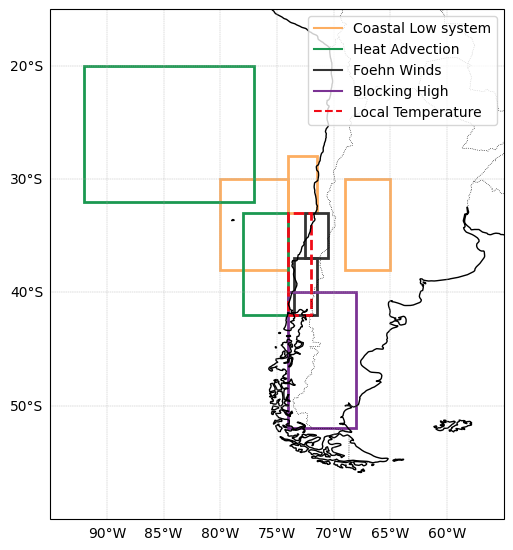

In [7]:
fig = plt.figure(figsize=(12, 6))
proj = ccrs.PlateCarree(central_longitude=180)
ax = plt.axes([0.05, 0.1, 0.9, 0.85], projection=proj)

# 🇨🇱 ZOOM INTO CHILE
ax.set_extent([265, 305, -60, -15], crs=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False
colors = {
    "enso": "#d73027",
    "blocking": "#7b3294",
    "synoptic": "#4575b4",
    "dmi": "#fdae61",
    "advection": "#1a9850",
    "coastal": "#fdae61",
    "winds": "#333333",
    "sam": "#12BBBB",
    "local": "#F10B17",
}
# Coastal Low
draw_box(ax, 291, 295, -38, -30,
         edgecolor=colors["coastal"], facecolor='none', linewidth=2)

draw_box(ax, 280, 286, -38, -30,
         edgecolor=colors["coastal"], facecolor='none', linewidth=2)

draw_box(ax, 286, 288.5, -33, -28,
         edgecolor=colors["coastal"], facecolor='none', linewidth=2)

# Heat advection
draw_box(ax, 268, 283, -32, -20,
         edgecolor=colors["advection"], facecolor='none', linewidth=2)

draw_box(ax, 282, 286, -42, -33,
         edgecolor=colors["advection"], facecolor='none', linewidth=2)

# Winds
draw_box(ax, 287.5, 289.5, -37, -33,
         edgecolor=colors["winds"], facecolor='none', linewidth=2)

draw_box(ax, 286.5, 288.5, -42, -37,
         edgecolor=colors["winds"], facecolor='none', linewidth=2)
draw_box(ax, 286, 292, -40, -52,
         edgecolor=colors["blocking"], facecolor='none', linewidth=2)

# Local Temp
draw_box(ax, 286, 288, -42, -33,
         edgecolor=colors["local"], facecolor='none',linestyle='--', linewidth=2)
legend_elements = [
    # mlines.Line2D([], [], color=colors["enso"], label='ENSO'),
    # mlines.Line2D([], [], color=colors["pdo"], label='PDO'),
    # mlines.Line2D([], [], color=colors["synoptic"], label='South Pacific Anticyclone'),
    mlines.Line2D([], [], color=colors["coastal"], label='Coastal Low system'),
    mlines.Line2D([], [], color=colors["advection"], label='Heat Advection'),
    mlines.Line2D([], [], color=colors["winds"], label='Foehn Winds'),
    mlines.Line2D([], [], color=colors["blocking"], label='Blocking High'),
    mlines.Line2D([], [], color=colors["local"], label='Local Temperature', linestyle="--"),
    # mlines.Line2D([], [], color=colors["winds"], label='Foehn Winds'),
    # mlines.Line2D([], [], color=colors["sam"], label='SAM'),
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True)

# plt.title("Regional Drivers over Central Chile")

plt.savefig("local_drivers.png", dpi=300, bbox_inches='tight')
plt.show()

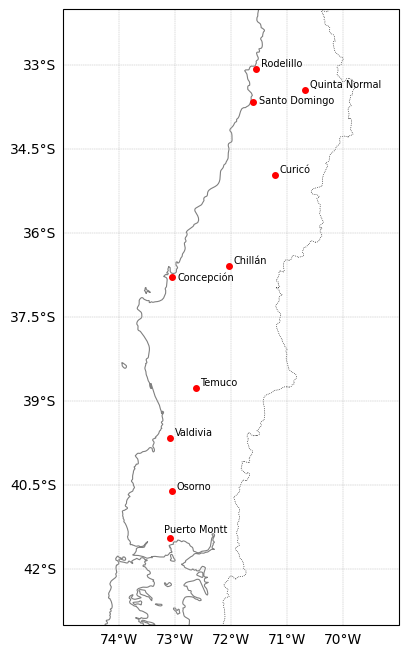

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------------------
# Stations
# ---------------------------
stations = [
    ("Rodelillo", -33.06528, -71.55639),
    ("Quinta Normal", -33.44500, -70.68278),
    ("Santo Domingo", -33.65611, -71.61333),
    ("Curicó", -34.96944, -71.21694),
    ("Chillán", -36.58583, -72.03667),
    ("Concepción", -36.78055, -73.06639),
    ("Temuco", -38.76778, -72.63194),
    ("Valdivia", -39.65667, -73.08722),
    ("Osorno", -40.61444, -73.05750),
    ("Puerto Montt", -41.44750, -73.09583),
]

# ---------------------------
# Figure
# ---------------------------
fig = plt.figure(figsize=(6, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Focus on Central-Southern Chile
ax.set_extent([-75, -69, -43, -32])

# Base map
ax.coastlines(linewidth=0.8, alpha=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# ---------------------------
# Plot stations
# ---------------------------
offsets = {
    "Rodelillo":(0.08, 0.05),
    "Quinta Normal":(0.08, 0.05),
    "Santo Domingo":(0.1, -0.03),
    "Curicó":(0.08, 0.05),
    "Chillán":(0.08, 0.05),
    "Concepción":(0.1, -0.05),
    "Temuco":(0.08, 0.05),
    "Valdivia":(0.08, 0.05),
    "Osorno":(0.08, 0.05),
    "Puerto Montt":(-0.1, 0.1),
}

for i, (name, lat, lon) in enumerate(stations):
    ax.plot(lon, lat, 'o', color='red', markersize=4,
            transform=ccrs.PlateCarree())
    
    dx, dy = offsets[name]
    ax.text(
        lon + dx, lat + dy,
        name,
        fontsize=7,
        transform=ccrs.PlateCarree()
    )

# ---------------------------
# plt.title("Meteorological Stations in Central-Southern Chile")

plt.savefig("stations_only.png", dpi=300, bbox_inches='tight')
plt.show()